# Transaction Costs & Turnover Analysis

## Objective

Evaluate whether the Momentum126 strategy remains profitable after realistic trading costs.

Research Questions:

- How much turnover does the portfolio generate?
- How sensitive is performance to transaction costs?
- Does the strategy remain attractive after implementation frictions?

Strategy:

- NIFTY 500 Universe
- Momentum126
- Top 20 Stocks
- Equal Weight
- 42-Day Rebalance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

close = pd.read_pickle(
    "../data/nifty500_close_clean.pkl"
)

mom126 = (
    close
    .pct_change(126)
    .shift(1)
)

In [2]:
rebalance_dates = close.index[126::42]

turnovers = []

previous_portfolio = None

for date in rebalance_dates:

    portfolio = set(
        mom126.loc[date]
        .dropna()
        .nlargest(20)
        .index
    )

    if previous_portfolio is not None:

        overlap = len(
            portfolio.intersection(
                previous_portfolio
            )
        )

        turnover = (
            20 - overlap
        ) / 20

        turnovers.append(
            turnover
        )

    previous_portfolio = portfolio

print(
    "Average Turnover:",
    np.mean(turnovers)
)

print(
    "Median Turnover:",
    np.median(turnovers)
)

Average Turnover: 0.5442622950819672
Median Turnover: 0.55


In [3]:
def backtest_costs(cost):

    rebalance_dates = close.index[
        126::42
    ]

    returns = []

    previous_portfolio = None

    for i in range(
        len(rebalance_dates)-1
    ):

        start = rebalance_dates[i]
        end = rebalance_dates[i+1]

        portfolio = set(
            mom126.loc[start]
            .dropna()
            .nlargest(20)
            .index
        )

        gross_return = (
            close.loc[end, list(portfolio)]
            /
            close.loc[start, list(portfolio)]
            - 1
        ).mean()

        turnover = 1

        if previous_portfolio is not None:

            overlap = len(
                portfolio.intersection(
                    previous_portfolio
                )
            )

            turnover = (
                20 - overlap
            ) / 20

        net_return = (
            gross_return
            -
            turnover * cost
        )

        returns.append(
            net_return
        )

        previous_portfolio = portfolio

    returns = pd.Series(
        returns,
        index=rebalance_dates[:-1]
    )

    equity = (
        1 + returns
    ).cumprod()

    cagr = (
        equity.iloc[-1]
        **
        (
            252 /
            len(close)
        )
        - 1
    )

    sharpe = (
        returns.mean()
        /
        returns.std()
    ) * np.sqrt(
        252/42
    )

    return {
        "Total Return":
            equity.iloc[-1]-1,
        "CAGR":
            cagr,
        "Sharpe":
            sharpe
    }

In [4]:
costs = [
    0.0005,   # 0.05%
    0.0010,   # 0.10%
    0.0025,   # 0.25%
    0.0050    # 0.50%
]

results = pd.DataFrame({
    f"{c*100:.2f}%":
    backtest_costs(c)
    for c in costs
}).T

results.to_csv(
    "../results/tables/05_cost_sensitivity.csv"
)

results


,Total Return,CAGR,Sharpe
0.05%,38.307705,0.405857,1.383007
0.10%,37.708294,0.403854,1.377718
0.25%,35.963421,0.397859,1.361849
0.50%,33.225457,0.387913,1.335389


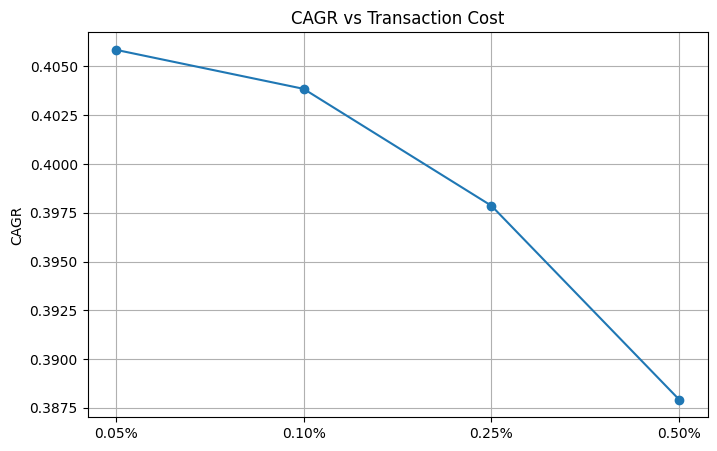

In [5]:
plt.figure(figsize=(8,5))

plt.plot(
    results.index,
    results["CAGR"],
    marker="o"
)

plt.title(
    "CAGR vs Transaction Cost"
)

plt.ylabel(
    "CAGR"
)

plt.grid(True)

plt.savefig(
    "../results/plots/05_cagr_vs_transaction_cost.png",
    bbox_inches="tight"
)

plt.show()

## Transaction Cost Analysis

Average Portfolio Turnover: 54.4%

Results:

| Cost | CAGR | Sharpe |
|--------|--------|--------|
| 0.05% | 40.59% | 1.38 |
| 0.10% | 40.39% | 1.38 |
| 0.25% | 39.79% | 1.36 |
| 0.50% | 38.79% | 1.34 |

Key Findings:

- Momentum126 remained profitable under all tested cost assumptions.
- CAGR declined only modestly as transaction costs increased.
- Sharpe ratio remained above 1.3 even at the highest cost level.
- Average turnover of 54% per rebalance indicates moderate trading activity.
- The strategy appears robust to realistic implementation costs.